<a href="https://colab.research.google.com/github/julia-zhmurko/JuliaZhmurko-ML/blob/main/%D0%A2%D1%80%D0%B5%D0%BD%D1%83%D0%B2%D0%B0%D0%BB%D1%8C%D0%BD%D1%96_%D0%BD%D0%BE%D1%83%D1%82%D0%B1%D1%83%D0%BA%D0%B8_%D0%B4%D0%BE_%D0%BB%D0%B5%D0%BA%D1%86%D1%96%D0%B9/%D0%96%D0%BC%D1%83%D1%80%D0%BA%D0%BE_%D0%AE%D0%BB%D1%96%D1%8F_%D0%A4%D0%86%D0%A2_4_10_%22%D0%A2%D1%80%D0%B5%D0%BD%D1%83%D0%B2%D0%B0%D0%BB%D1%8C%D0%BD%D0%B8%D0%B9_%D0%BD%D0%BE%D1%83%D1%82%D0%B1%D1%83%D0%BA_%D0%9B%D0%B5%D0%BA%D1%86%D1%96%D1%8F_3_Pandas_EDA_2026_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Тренувальний ноутбук до лекції 3
## Аналіз даних у pandas та EDA

**Дисципліна:** Машинне навчання  
**Редакція:** 2026  

Мета ноутбука - відпрацювати основні операції pandas на єдиному навчальному наборі даних: завантаження, первинне обстеження, індексацію, очищення, групування, об’єднання, переформатування та базову візуалізацію.

> Матеріал орієнтований на pandas 3.0+. Якщо у Google Colab встановлена інша версія, більшість прикладів все одно виконуватиметься, але dtype текстових стовпців може відрізнятися.

## 0. Підготовка середовища

Спочатку імпортуємо бібліотеки та перевіримо версію pandas.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("pandas:", pd.__version__)
print("numpy:", np.__version__)

pandas: 2.2.3
numpy: 2.1.3


## 1. Створення навчального набору даних

Щоб ноутбук був автономним і запускався у Colab без зовнішніх файлів, згенеруємо невеликий набір даних про клієнтів інтернет-магазину. У ньому навмисно є пропуски, дублікати та неакуратні текстові значення.

In [6]:
rng = np.random.default_rng(42)

n = 120
cities = np.array(["Kyiv", "Lviv", "Odesa", "Dnipro", "Kharkiv"])
segments = np.array(["basic", "standard", "premium"])

customers = pd.DataFrame({
    "customer_id": np.arange(1001, 1001 + n),
    "age": rng.integers(18, 70, size=n),
    "city": rng.choice(cities, size=n, p=[0.30, 0.20, 0.18, 0.16, 0.16]),
    "segment": rng.choice(segments, size=n, p=[0.45, 0.40, 0.15]),
    "signup_date": pd.Timestamp("2022-01-01") + pd.to_timedelta(
        rng.integers(0, 1600, size=n), unit="D"
    ),
    "orders": rng.poisson(7, size=n),
    "spend": np.round(rng.gamma(shape=2.3, scale=280, size=n), 2),
    "churn": rng.choice([0, 1], size=n, p=[0.78, 0.22]),
})

# Навмисно додаємо проблеми якості даних
customers.loc[[5, 18, 44], "age"] = np.nan
customers.loc[[9, 27, 78, 101], "spend"] = np.nan
customers.loc[12, "city"] = " kyiv "
customers.loc[31, "city"] = "LVIV"
customers.loc[66, "segment"] = None
customers.loc[88, "spend"] = -150.0

# Додаємо два дублікати рядків
customers = pd.concat([customers, customers.iloc[[3, 15]]], ignore_index=True)

customers.to_csv("customers_eda.csv", index=False)
print("Файл створено: customers_eda.csv")
print("Розмір:", customers.shape)
customers.head()

Файл створено: customers_eda.csv
Розмір: (122, 8)


,customer_id,age,city,segment,signup_date,orders,spend,churn
0,1001,22.0,Odesa,premium,2024-09-13,4,347.14,0
1,1002,58.0,Lviv,premium,2025-05-31,9,706.18,0
2,1003,52.0,Odesa,standard,2025-03-28,11,1164.91,0
3,1004,40.0,Dnipro,basic,2022-08-04,7,77.99,0
4,1005,40.0,Odesa,standard,2025-08-14,8,574.75,0


## 2. Завантаження даних та первинна перевірка

Завантажимо CSV так, як це робиться у реальному проєкті.

In [7]:
df = pd.read_csv(
    "customers_eda.csv",
    parse_dates=["signup_date"],
)

print("shape:", df.shape)
print("columns:", df.columns.tolist())
df.head()

shape: (122, 8)
columns: ['customer_id', 'age', 'city', 'segment', 'signup_date', 'orders', 'spend', 'churn']


,customer_id,age,city,segment,signup_date,orders,spend,churn
0,1001,22.0,Odesa,premium,2024-09-13,4,347.14,0
1,1002,58.0,Lviv,premium,2025-05-31,9,706.18,0
2,1003,52.0,Odesa,standard,2025-03-28,11,1164.91,0
3,1004,40.0,Dnipro,basic,2022-08-04,7,77.99,0
4,1005,40.0,Odesa,standard,2025-08-14,8,574.75,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   customer_id  122 non-null    int64         
 1   age          119 non-null    float64       
 2   city         122 non-null    object        
 3   segment      121 non-null    object        
 4   signup_date  122 non-null    datetime64[ns]
 5   orders       122 non-null    int64         
 6   spend        118 non-null    float64       
 7   churn        122 non-null    int64         
dtypes: datetime64[ns](1), float64(2), int64(3), object(2)
memory usage: 7.8+ KB


In [10]:
df.describe()

,customer_id,age,signup_date,orders,spend,churn
count,122.000000,119.000000,122,122.000000,118.000000,122.000000
mean,1059.672131,44.512605,2024-04-23 11:00:59.016393472,6.959016,672.393814,0.278689
min,1001.000000,18.000000,2022-01-13 00:00:00,1.000000,-150.000000,0.000000
25%,1029.250000,33.000000,2023-05-01 06:00:00,5.000000,341.800000,0.000000
50%,1059.500000,44.000000,2024-05-06 12:00:00,7.000000,621.640000,0.000000
75%,1089.750000,57.000000,2025-03-27 06:00:00,8.000000,901.750000,1.000000
max,1120.000000,68.000000,2026-05-14 00:00:00,14.000000,2046.770000,1.000000
std,35.100668,14.038606,NaN,2.556462,445.379828,0.450203


### Зверніть увагу
- `shape` показує кількість об'єктів та ознак;
- `info()` допомагає побачити типи й пропуски;
- `describe()` дає базову статистику числових ознак;
- у pandas 3.0 текстові стовпці за замовчуванням можуть мати `str` dtype замість старого `object`.

## 3. Series, DataFrame, loc та iloc

In [12]:
# Один стовпець -> Series
spend = df["spend"]
print(type(spend))

# Кілька стовпців -> DataFrame
small = df[["customer_id", "city", "spend"]]
print(type(small))
small.head()

<class 'pandas.core.series.Series'>
<class 'pandas.core.frame.DataFrame'>


,customer_id,city,spend
0,1001,Odesa,347.14
1,1002,Lviv,706.18
2,1003,Odesa,1164.91
3,1004,Dnipro,77.99
4,1005,Odesa,574.75


In [14]:
# loc: вибір за мітками / умовами
high_spend = df.loc[df["spend"] > 1000, ["customer_id", "city", "spend"]]
print(high_spend.head())

# iloc: вибір за позиціями
print(df.iloc[:5, :4])

    customer_id    city    spend
2          1003   Odesa  1164.91
6          1007   Odesa  1771.49
15         1016    Kyiv  1190.51
19         1020  Dnipro  1632.17
21         1022    Lviv  1162.84
   customer_id   age    city   segment
0         1001  22.0   Odesa   premium
1         1002  58.0    Lviv   premium
2         1003  52.0   Odesa  standard
3         1004  40.0  Dnipro     basic
4         1005  40.0   Odesa  standard


## 4. Фільтрація даних

In [16]:
mask = (
    df["age"].between(25, 45)
    & df["city"].isin(["Kyiv", "Lviv"])
    & df["spend"].notna()
)

selected = df.loc[mask]
selected.head()

,customer_id,age,city,segment,signup_date,orders,spend,churn
8,1009,28.0,Kyiv,standard,2026-03-28,5,409.81,1
10,1011,45.0,Kyiv,premium,2025-08-26,8,134.76,0
16,1017,44.0,Kyiv,standard,2023-02-04,5,425.17,0
21,1022,37.0,Lviv,premium,2024-02-04,8,1162.84,0
30,1031,41.0,Kyiv,standard,2025-03-25,4,851.50,0


In [17]:
# query часто зручний для читабельних числових умов
query_result = df.query("orders >= 8 and spend > 700")
query_result.head()

,customer_id,age,city,segment,signup_date,orders,spend,churn
1,1002,58.0,Lviv,premium,2025-05-31,9,706.18,0
2,1003,52.0,Odesa,standard,2025-03-28,11,1164.91,0
13,1014,57.0,Kyiv,standard,2023-09-09,10,902.89,1
15,1016,58.0,Kyiv,basic,2024-10-20,8,1190.51,1
17,1018,24.0,Odesa,premium,2023-03-03,13,930.86,0


## 5. Пропуски, дублікати та базове очищення

In [18]:
missing = pd.DataFrame({
    "count": df.isna().sum(),
    "share": df.isna().mean(),
}).sort_values("share", ascending=False)

missing

,count,share
spend,4,0.032787
age,3,0.024590
segment,1,0.008197
customer_id,0,0.000000
city,0,0.000000
signup_date,0,0.000000
orders,0,0.000000
churn,0,0.000000


In [21]:
print("Повних дублікатів:", df.duplicated().sum())
print("Дублікатів customer_id:", df.duplicated(subset=["customer_id"]).sum())

Повних дублікатів: 2
Дублікатів customer_id: 2


In [23]:
clean = df.drop_duplicates().copy()

# Негативні витрати трактуємо як помилкове значення
clean.loc[clean["spend"] < 0, "spend"] = np.nan

# Очищення тексту
clean["city"] = clean["city"].str.strip().str.title()
clean["segment"] = clean["segment"].fillna("unknown")

print(clean.shape)
print(clean["city"].value_counts(dropna=False))
print(clean["segment"].value_counts(dropna=False))

(120, 8)
city
Kyiv       38
Lviv       28
Odesa      24
Dnipro     16
Kharkiv    14
Name: count, dtype: int64
segment
basic       58
standard    43
premium     18
unknown      1
Name: count, dtype: int64


### Примітка про ML
У цьому навчальному EDA можна показати заповнення пропусків. Але якщо значення для заповнення (медіана, середнє тощо) використовуватиметься моделлю, його слід оцінювати **лише на train**, бажано всередині `Pipeline`.

In [24]:
# Для дослідницького аналізу створимо окремий стовпець
median_age = clean["age"].median()
clean["age_filled"] = clean["age"].fillna(median_age)

print("Медіана age:", median_age)
clean[["age", "age_filled"]].head(10)

Медіана age: 44.0


,age,age_filled
0,22.0,22.0
1,58.0,58.0
2,52.0,52.0
3,40.0,40.0
4,40.0,40.0
5,NaN,44.0
6,22.0,22.0
7,54.0,54.0
8,28.0,28.0
9,22.0,22.0


## 6. Робота з датами та створення ознак

In [26]:
reference_date = pd.Timestamp("2026-09-07")

clean["signup_year"] = clean["signup_date"].dt.year
clean["signup_month"] = clean["signup_date"].dt.month
clean["tenure_days"] = (reference_date - clean["signup_date"]).dt.days
clean["spend_per_order"] = clean["spend"] / clean["orders"].replace(0, np.nan)

clean[[
    "signup_date", "signup_year", "signup_month",
    "tenure_days", "spend_per_order"
]].head()

,signup_date,signup_year,signup_month,tenure_days,spend_per_order
0,2024-09-13,2024,9,724,86.785000
1,2025-05-31,2025,5,464,78.464444
2,2025-03-28,2025,3,528,105.900909
3,2022-08-04,2022,8,1495,11.141429
4,2025-08-14,2025,8,389,71.843750


## 7. Сортування, groupby та агрегування

In [28]:
top_customers = clean.sort_values("spend", ascending=False).head(10)
top_customers[["customer_id", "city", "segment", "spend"]]

,customer_id,city,segment,spend
34,1035,Lviv,standard,2046.77
67,1068,Kyiv,basic,1972.21
6,1007,Odesa,basic,1771.49
59,1060,Odesa,basic,1653.40
29,1030,Odesa,standard,1651.09
19,1020,Dnipro,basic,1632.17
99,1100,Dnipro,premium,1528.80
84,1085,Lviv,premium,1386.54
57,1058,Dnipro,standard,1358.35
51,1052,Kyiv,basic,1355.64


In [29]:
city_summary = (
    clean.groupby("city", dropna=False)
         .agg(
             customers=("customer_id", "nunique"),
             avg_spend=("spend", "mean"),
             median_spend=("spend", "median"),
             total_spend=("spend", "sum"),
             churn_rate=("churn", "mean"),
         )
         .sort_values("total_spend", ascending=False)
)

city_summary.round(2)

,customers,avg_spend,median_spend,total_spend,churn_rate
city,,,,,
Kyiv,38,678.75,682.37,25792.35,0.26
Lviv,28,705.33,704.74,17633.17,0.21
Odesa,24,655.27,527.90,15726.52,0.38
Dnipro,16,688.37,479.96,10325.49,0.19
Kharkiv,14,672.80,637.44,8746.44,0.36


In [30]:
# transform повертає результат тієї самої довжини, що й початкові дані
city_total = clean.groupby("city")["spend"].transform("sum")
clean["share_in_city"] = clean["spend"] / city_total

clean[["customer_id", "city", "spend", "share_in_city"]].head()

,customer_id,city,spend,share_in_city
0,1001,Odesa,347.14,0.022074
1,1002,Lviv,706.18,0.040048
2,1003,Odesa,1164.91,0.074073
3,1004,Dnipro,77.99,0.007553
4,1005,Odesa,574.75,0.036547


## 8. merge та concat

In [31]:
city_info = pd.DataFrame({
    "city": ["Kyiv", "Lviv", "Odesa", "Dnipro", "Kharkiv"],
    "region": ["North", "West", "South", "Center", "East"],
    "priority_market": [1, 1, 0, 0, 1],
})

merged = clean.merge(
    city_info,
    on="city",
    how="left",
    validate="many_to_one",
    indicator=True,
)

print(merged["_merge"].value_counts())
merged.head()

_merge
both          120
left_only       0
right_only      0
Name: count, dtype: int64


,customer_id,age,city,segment,signup_date,orders,spend,churn,age_filled,signup_year,signup_month,tenure_days,spend_per_order,share_in_city,region,priority_market,_merge
0,1001,22.0,Odesa,premium,2024-09-13,4,347.14,0,22.0,2024,9,724,86.785000,0.022074,South,0,both
1,1002,58.0,Lviv,premium,2025-05-31,9,706.18,0,58.0,2025,5,464,78.464444,0.040048,West,1,both
2,1003,52.0,Odesa,standard,2025-03-28,11,1164.91,0,52.0,2025,3,528,105.900909,0.074073,South,0,both
3,1004,40.0,Dnipro,basic,2022-08-04,7,77.99,0,40.0,2022,8,1495,11.141429,0.007553,Center,0,both
4,1005,40.0,Odesa,standard,2025-08-14,8,574.75,0,40.0,2025,8,389,71.843750,0.036547,South,0,both


In [32]:
first_half = clean.iloc[:60]
second_half = clean.iloc[60:]
restored = pd.concat([first_half, second_half], ignore_index=True)

print(clean.shape, restored.shape)

(120, 14) (120, 14)


## 9. pivot_table, crosstab та melt

In [33]:
pivot = pd.pivot_table(
    clean,
    values="spend",
    index="city",
    columns="segment",
    aggfunc="mean",
    fill_value=0,
)

pivot.round(2)

segment,basic,premium,standard,unknown
city,,,,
Dnipro,638.73,979.02,583.47,0.00
Kharkiv,602.54,762.48,750.92,0.00
Kyiv,715.81,598.02,657.28,0.00
Lviv,706.03,700.24,696.94,777.76
Odesa,730.47,639.00,605.72,0.00


In [34]:
churn_table = pd.crosstab(
    clean["segment"],
    clean["churn"],
    normalize="index",
)

churn_table.round(3)

churn,0,1
segment,,
basic,0.759,0.241
premium,0.778,0.222
standard,0.674,0.326
unknown,0.000,1.000


In [35]:
wide = city_summary.reset_index()[["city", "avg_spend", "churn_rate"]]
long = wide.melt(
    id_vars="city",
    var_name="metric",
    value_name="value",
)
long.head(10)

,city,metric,value
0,Kyiv,avg_spend,678.746053
1,Lviv,avg_spend,705.326800
2,Odesa,avg_spend,655.271667
3,Dnipro,avg_spend,688.366000
4,Kharkiv,avg_spend,672.803077
5,Kyiv,churn_rate,0.263158
6,Lviv,churn_rate,0.214286
7,Odesa,churn_rate,0.375000
8,Dnipro,churn_rate,0.187500
9,Kharkiv,churn_rate,0.357143


## 10. Кореляція та пошук потенційних викидів

In [36]:
numeric_cols = ["age", "orders", "spend", "churn", "tenure_days"]
correlation = clean[numeric_cols].corr(method="pearson")
correlation.round(2)

,age,orders,spend,churn,tenure_days
age,1.00,-0.05,-0.08,0.08,0.01
orders,-0.05,1.00,-0.08,-0.05,-0.07
spend,-0.08,-0.08,1.00,-0.01,-0.02
churn,0.08,-0.05,-0.01,1.00,-0.15
tenure_days,0.01,-0.07,-0.02,-0.15,1.00


In [37]:
q1 = clean["spend"].quantile(0.25)
q3 = clean["spend"].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = clean.loc[~clean["spend"].between(lower, upper) & clean["spend"].notna()]
print("Межі IQR:", round(lower, 2), round(upper, 2))
print("Кількість потенційних викидів:", len(outliers))
outliers[["customer_id", "city", "spend"]].head()

Межі IQR: -480.7 1729.4
Кількість потенційних викидів: 3


,customer_id,city,spend
6,1007,Odesa,1771.49
34,1035,Lviv,2046.77
67,1068,Kyiv,1972.21


## 11. Базова візуалізація

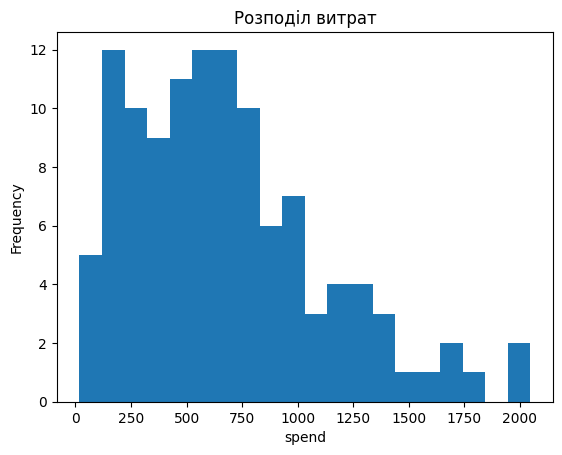

In [38]:
clean["spend"].plot(kind="hist", bins=20, title="Розподіл витрат")
plt.xlabel("spend")
plt.show()

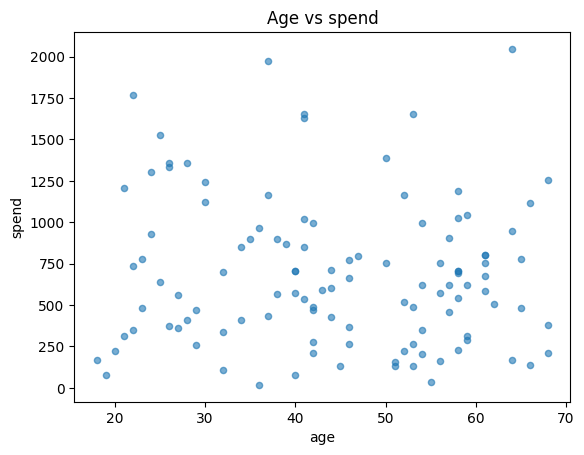

In [39]:
clean.plot.scatter(x="age", y="spend", alpha=0.6, title="Age vs spend")
plt.show()

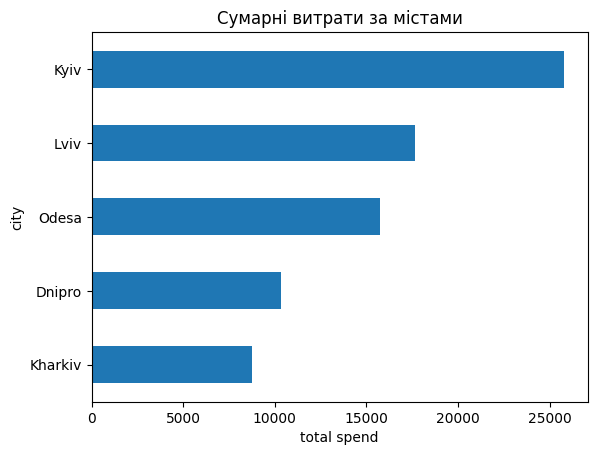

In [40]:
city_summary["total_spend"].sort_values().plot(
    kind="barh",
    title="Сумарні витрати за містами",
)
plt.xlabel("total spend")
plt.show()

## 12. EDA і data leakage

Нижче показано лише **правильну послідовність**: спочатку train/test split, потім статистики preprocessing оцінюються на train.

In [42]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    clean,
    test_size=0.2,
    random_state=42,
    stratify=clean["churn"],
)

train_median = train_df["age"].median()
train_age = train_df["age"].fillna(train_median)
test_age = test_df["age"].fillna(train_median)

print("train:", train_df.shape)
print("test:", test_df.shape)
print("Медіана, оцінена лише на train:", train_median)

train: (96, 14)
test: (24, 14)
Медіана, оцінена лише на train: 44.0


# Завдання для студентів

Виконайте завдання нижче самостійно. Після кожного завдання додайте короткий висновок у Markdown-комірці: **що саме було виявлено і чому це важливо**.

## Завдання 1. Первинний аудит даних
1. Визначте розмір `df`.
2. Виведіть типи всіх стовпців.
3. Порахуйте кількість унікальних значень у кожному стовпці.
4. Визначте частку пропусків.
5. Назвіть щонайменше три потенційні проблеми якості даних.

In [54]:
# TODO: Ваш код для завдання 1
#1
print("Розмір DataFrame (рядки, стовпчики):", df.shape)

#2
print("\nТипи всіх стовпців DataFrame:\n")
print(df.dtypes)

#3
print("\nКількість унікальних значень у кожному стовпці DataFrame:\n")
print(df.nunique(dropna=False))

#4
print("\nЧастка пропусків у кожному стовпці:\n")
print(df.isna().mean().round(4))

Розмір DataFrame (рядки, стовпчики): (122, 8)

Типи всіх стовпців DataFrame:

customer_id             int64
age                   float64
city                   object
segment                object
signup_date    datetime64[ns]
orders                  int64
spend                 float64
churn                   int64
dtype: object

Кількість унікальних значень у кожному стовпці DataFrame:

customer_id    120
age             46
city             7
segment          4
signup_date    117
orders          14
spend          117
churn            2
dtype: int64

Частка пропусків у кожному стовпці:

customer_id    0.0000
age            0.0246
city           0.0000
segment        0.0082
signup_date    0.0000
orders         0.0000
spend          0.0328
churn          0.0000
dtype: float64


### Висновок за результатами первинного аудиту даних (Завдання 1):

1. **Розмірність датасету:** `df` містить 122 рядки та 8 стовпчиків.
2. **Типи даних:** Більшість колонок мають відповідні типи (`float64`, `int64`, `datetime64[ns]`, `object`).
3. **Унікальні значення:** У колонці `customer_id` наявні 120 унікальних значень при загальній кількості 122 рядки, що вказує на наявність дублікатів.
4. **Пропущені значення:** Виявлено пропуски у колонках `age` (2.46%), `segment` (0.82%) та `spend` (3.28%).

**5.** **Три потенційні проблеми якості даних:**
   - **Дублікати:** Загальна кількість рядків (122) перевищує кількість унікальних `customer_id` (120), тобто у датасеті є 2 дубльовані записи.
   - **Пропущені значення (`NaN`):** Наявність пропусків у колонках (`age`, `spend`, `segment`).
   - **Нерегулярність у категоріях:** Колонка `city` має 7 унікальних значень замість стандартних  5 міст, що вказує на наявність некоректних або дубльованих назв (наприклад, `LVIV` та `kyiv`).

**Чому це важливо:** Неочищені дані з дублікатами та пропусками викривляють підсумкові агрегації та описову статистику, що призводить до хибних бізнес-висновків.

## Завдання 2. Фільтрація
Створіть DataFrame `task2`, який містить клієнтів:
- віком від 30 до 50 років;
- із сегменту `premium` або `standard`;
- з витратами понад 600;
- лише зі стовпцями `customer_id`, `age`, `city`, `segment`, `spend`.

Відсортуйте результат за `spend` за спаданням.

In [61]:
# TODO: Ваш код для завдання 2
#1
chosen_age = df[(df["age"] >= 30) & (df["age"] <= 50)]
print("Після фільтрації за віком (30-50):", len(chosen_age))

#2
chosen_standard = chosen_age[chosen_age["segment"].isin(["premium", "standard"])]
print("Після фільтрації за сегментом (premium/standard):", len(chosen_standard))

#3
spend_more = chosen_standard[chosen_standard["spend"] > 600]
print("Після фільтрації за витратами (>600):", len(spend_more))

#4
cols = ["customer_id", "age", "city", "segment", "spend"]
only_cols = spend_more[cols]

task2 = only_cols.sort_values(by = "spend", ascending = False)
print("Підсумковий DataFrame task2 (перші 10 рядків):\n")
task2.head(10)

Після фільтрації за віком (30-50): 44
Після фільтрації за сегментом (premium/standard): 28
Після фільтрації за витратами (>600): 16
Підсумковий DataFrame task2 (перші 10 рядків):



,customer_id,age,city,segment,spend
29,1030,41.0,Odesa,standard,1651.09
84,1085,50.0,Lviv,premium,1386.54
118,1119,30.0,Kharkiv,standard,1243.22
21,1022,37.0,Lviv,premium,1162.84
75,1076,42.0,Kyiv,standard,997.35
43,1044,36.0,Kharkiv,premium,963.23
76,1077,35.0,Kharkiv,standard,898.33
64,1065,39.0,Kyiv,standard,870.96
30,1031,41.0,Kyiv,standard,851.50
65,1066,34.0,Lviv,premium,848.28


### Висновок за результатами фільтрації (Завдання 2):

1. **Кроки фільтрації:**
   - Відбір за віком [30, 50] звузив вибірку до клієнтів активного працездатного віку.
   - Застосування фільтра за сегментами прибрало записи із базовими (`basic`) значеннями.
   - Відбір за витратами (> 600) залишив лише платтоспроможну аудиторію.
2. **Форматування та сортування:** Колонки датасету обмежено до 5 необхідних, а результати впорядковано від найбільших витрат до найменших.

**Чому це важливо:** Покрокова фільтрація дає змогу виділити найбільш цінну цільову групу клієнтів для подальшого аналізу та проведення маркетингових досліджень.

## Завдання 3. Очищення
На копії `df` виконайте:
1. видалення повних дублікатів;
2. очищення пробілів і регістру в `city`;
3. заміну від’ємних `spend` на пропуск;
4. підрахунок кількості пропусків після очищення;
5. поясніть, які пропуски ви б видаляли, а які — імпутували.

In [69]:
# TODO: Ваш код для завдання 3
df_cleaned = df.copy()

#1
initial_rows = len(df_cleaned)
df_cleaned = df_cleaned.drop_duplicates()
print("Видалено повних дублікатів:", initial_rows - len(df_cleaned))

#2
df_cleaned["city"] = df_cleaned["city"].str.strip().str.title()
print("Унікальні міста після очищення:")
print(df_cleaned["city"].unique())

#3
negative_spend_count = (df_cleaned["spend"] < 0).sum()
df_cleaned.loc[df_cleaned["spend"] < 0, "spend"] = np.nan
print(f"\nЗамінено від'ємних значень spend на NaN:", negative_spend_count)

#4
print("\nКількість пропусків у кожному стовпці після очищення:")
print(df_cleaned.isna().sum())

Видалено повних дублікатів: 2
Унікальні міста після очищення:
['Odesa' 'Lviv' 'Dnipro' 'Kyiv' 'Kharkiv']

Замінено від'ємних значень spend на NaN: 1

Кількість пропусків у кожному стовпці після очищення:
customer_id    0
age            3
city           0
segment        1
signup_date    0
orders         0
spend          5
churn          0
dtype: int64


### Висновок за результатами очищення даних (Завдання 3):

1. **Дублікати та форматування:** Видалено дубльовані записи, а в значеннях колонки `city` видалено зайві пробіли та виконано зведення до єдиного регістру.
2. **Аномальні значення:** Від'ємні показники витрат у колонці `spend` замінено на `NaN`, оскільки сума витрат не може бути меншою за нуль.
3. **Підсумковий стан пропусків:** Отримано оновлену статистику відсутніх значень для всіх колонок.

**5. Способи обробки пропусків (видалення/імпутація):**

* **Видалення (`drop`):** Застосовувати у випадку, якщо пропуски наявні в ключових ідентифікаторах (наприклад, `customer_id`), або якщо запис містить пропуски у більшості колонок одночасно. Також видалення доцільне, коли частка пропусків у колонці є незначною (до 1–2%) і їх видалення не спотворить загальну вибірку.
  
* **Імпутація (`imputation`):** Використовувати із числовими змінними (`age`, `spend`) заповненими медіаною або середнім значенням (групованим за сегментом чи містом), щоб зберегти розмірність вибірки та не втрачати інформацію з інших колонок.
  
**Чому це важливо:** Некоректні від'ємні значення та текст спотворюють групування та розрахунки, а правильний вибір між видаленням та імпутацією запобігає втраті даних і зміщенню статистичних показників.

## Завдання 4. Групова аналітика
Для кожного `segment` обчисліть:
- кількість клієнтів;
- середню кількість замовлень;
- медіанні витрати;
- сумарні витрати;
- churn rate.

Відсортуйте сегменти за churn rate від найбільшого до найменшого.

In [70]:
# TODO: Ваш код для завдання 4
#1
task4 = df_cleaned.groupby("segment", dropna = False).agg(
    customer_count=("customer_id", "count"),
    avg_orders=("orders", "mean"),
    median_spend=("spend", "median"),
    total_spend=("spend", "sum"),
    churn_rate=("churn", "mean")
)

#2
task4 = task4.sort_values(by = "churn_rate", ascending = False)
print("Результати групової аналітики за сегментами:")
task4

Результати групової аналітики за сегментами:


,customer_count,avg_orders,median_spend,total_spend,churn_rate
segment,,,,,
NaN,1,6.000000,777.760,777.76,1.000000
standard,43,7.000000,503.860,27178.88,0.325581
basic,58,6.793103,668.135,37335.78,0.241379
premium,18,7.388889,738.405,12931.55,0.222222


### Висновок за результатами групової аналітики (Завдання 4):

1. **Метрики сегментів:**
   - Для кожного сегмента обчислено розмір аудиторії, середню активність (`avg_orders`), медіанні та сумарні витрати (`spend`), а також показник відтоку (`churn_rate`).
2. **Сортування та відтік:**
   - Сегменти впорядковано за рівнем відтоку клієнтів у порядку спадання для кращого виявлення найбільш проблемних груп.

**Чому це важливо:** Порівняльний аналіз сегментів за метриками цінності (total spend, median spend) та ризику (churn rate) допомагає бізнесу зосереджувати зусилля на утриманні високоцінних клієнтів та вчасно реагувати на ризики відтоку.

## Завдання 5. Ознаки на основі дат
Створіть:
- `signup_year`;
- `signup_quarter`;
- `tenure_days` станом на 07.09.2026.

Після цього визначте, у якому році зареєструвалося найбільше клієнтів.

In [79]:
# TODO: Ваш код для завдання 5
df_cleaned["signup_date"] = pd.to_datetime(df_cleaned["signup_date"])

#1
df_cleaned["signup_year"] = df_cleaned["signup_date"].dt.year
print("Додано signup_year. Перелік років у базі:")
print(df_cleaned["signup_year"].unique())

#2
df_cleaned["signup_quarter"] = df_cleaned["signup_date"].dt.quarter
print("\nДодано signup_quarter. Перелік кварталів у базі:")
print(df_cleaned["signup_quarter"].unique())

#3
target_date = pd.to_datetime("2026-09-07")
df_cleaned["tenure_days"] = (target_date - df_cleaned["signup_date"]).dt.days
print("\nДодано tenure_days. Перші 5 значень станом на 07.09.2026:\n")
print(df_cleaned[["customer_id", "signup_date", "tenure_days"]].head())

top_year = df_cleaned["signup_year"].value_counts().idxmax()
top_year_count = df_cleaned["signup_year"].value_counts().max()

print(f"\nНайбільше клієнтів зареєструвалося у {top_year} році ({top_year_count} осіб)")

print("\nПерші 5 рядків DataFrame із новими ознаками:")
df_cleaned[["customer_id", "signup_date", "signup_year", "signup_quarter", "tenure_days"]].head()

Додано signup_year. Перелік років у базі:
[2024 2025 2022 2023 2026]

Додано signup_quarter. Перелік кварталів у базі:
[3 2 1 4]

Додано tenure_days. Перші 5 значень станом на 07.09.2026:

   customer_id signup_date  tenure_days
0         1001  2024-09-13          724
1         1002  2025-05-31          464
2         1003  2025-03-28          528
3         1004  2022-08-04         1495
4         1005  2025-08-14          389

Найбільше клієнтів зареєструвалося у 2024 році (37 осіб)

Перші 5 рядків DataFrame із новими ознаками:


,customer_id,signup_date,signup_year,signup_quarter,tenure_days
0,1001,2024-09-13,2024,3,724
1,1002,2025-05-31,2025,2,464
2,1003,2025-03-28,2025,1,528
3,1004,2022-08-04,2022,3,1495
4,1005,2025-08-14,2025,3,389


### Висновок за результатами роботи з датами (Завдання 5):

1. **Генерація часових ознак:**
   - На основі дати реєстрації (`signup_date`) виділено рік (`signup_year`) та квартал (`signup_quarter`), що дозволяє проводити часову сегментацію клієнтської бази.
   - Розраховано стаж клієнта у днях (`tenure_days`) відносно контрольної дати `07.09.2026`.

2. **Аналіз активності за роками:**
   - За допомогою `value_counts()` визначено піковий рік за кількістю нових реєстрацій.

**Чому це важливо:** Створення часових метрик (особливо стажу клієнта `tenure_days`) є важливим для аналізу життєвого циклу клієнта, оцінки ефективності маркетингових кампаній різних років та побудови моделей прогнозування відтоку (churn rate).

## Завдання 6. Об’єднання таблиць
Створіть окрему таблицю `segment_info` з полями:
- `segment`;
- `discount_rate`;
- `support_level`.

Об’єднайте її з очищеним набором через `merge`. Обов’язково використайте `validate` і поясніть, який тип зв’язку очікується.

In [82]:
# TODO: Ваш код для завдання 6
#1
segment_info = pd.DataFrame({
    "segment": ["basic", "standard", "premium"],
    "discount_rate": [0.00, 0.05, 0.15],
    "support_level": ["Standard", "Priority", "VIP"]
})

print("Створена таблиця segment_info:\n")
print(segment_info)

#2
df_merged = pd.merge(
    df_cleaned,
    segment_info,
    on="segment",
    how="left",
    validate="many_to_one"
)

print("\nПерші 5 рядків об'єднаного датасету:")
df_merged[["customer_id", "segment", "discount_rate", "support_level"]].head()

Створена таблиця segment_info:

    segment  discount_rate support_level
0     basic           0.00      Standard
1  standard           0.05      Priority
2   premium           0.15           VIP

Перші 5 рядків об'єднаного датасету:


,customer_id,segment,discount_rate,support_level
0,1001,premium,0.15,VIP
1,1002,premium,0.15,VIP
2,1003,standard,0.05,Priority
3,1004,basic,0.00,Standard
4,1005,standard,0.05,Priority


### Висновок за результатами об'єднання таблиць (Завдання 6):

1. **Створення довідника:**
   - Створено допоміжну таблицю `segment_info` з атрибутами знижок (`discount_rate`) та рівня підтримки (`support_level`) для кожного сегмента.

2. **Тип зв'язку та валідація:**
   - Для об'єднання використано параметр `validate="many_to_one"`.
   - **Пояснення типу зв'язку:** У лівій таблиці (`df_cleaned`) кожен сегмент повторюється багаторазово (у багатьох клієнтів може бути однакова категорія `basic` чи `standard`), тоді як у правій таблиці довідника (`segment_info`) кожен сегмент є унікальним значенням (один запис на сегмент), тому використовується зв'язок **"багато-до-одного"**.
   - Використання `validate="many_to_one"` гарантує відсутність незапланованого дублювання рядків під час з'єднання.

**Чому це важливо:** Нормалізація даних шляхом винесення категоріальних параметрів у окремі довідники зменшує дублювання інформації в базі, а валідація під час об'єднання (`validate`) дозволяє запобігти помилкам розмноження рядків, які спотворюють аналітику.

## Завдання 7. Pivot table
Побудуйте `pivot_table`, де:
- рядки — `city`;
- стовпці — `segment`;
- значення — медіана `spend`.

Визначте комбінацію місто–сегмент із найбільшою медіаною витрат.

In [87]:
# TODO: Ваш код для завдання 7
pivot_spend = df_cleaned.pivot_table(
    index="city",
    columns="segment",
    values="spend",
    aggfunc="median"
)

print("Зведена таблиця (медіана витрат spend):\n")
print(pivot_spend)

max_spend_combination = pivot_spend.unstack().idxmax()
max_spend_value = pivot_spend.unstack().max()

best_segment = max_spend_combination[0]
best_city = max_spend_combination[1]

print("\nНайбільша медіана витрат:", max_spend_value)
print(f"Комбінація місто–сегмент: Місто '{best_city}', Сегмент '{best_segment}'")

Зведена таблиця (медіана витрат spend):

segment   basic   premium  standard
city                               
Dnipro   703.23  1254.480   456.840
Kharkiv  533.90   762.485   767.885
Kyiv     663.68   701.060   727.895
Lviv     679.78   777.230   425.100
Odesa    672.59   639.000   489.180

Найбільша медіана витрат: 1254.48
Комбінація місто–сегмент: Місто 'Dnipro', Сегмент 'premium'


### Висновок за результатами побудови зведеної таблиці (Завдання 7):

1. **Двовимірний аналіз:**
   - За допомогою `pivot_table` сформовано матрицю залежності медіанних витрат (`spend`) від міст (`city`) та рівня клієнта (`segment`).
   
2. **Максимальне значення:**
   - За допомогою методів `unstack()` та `idxmax()` автоматично виявлено конкретну комбінацію міста та сегмента, де клієнти мають найвище значення медіани витрат.

**Чому це важливо:** Зведені таблиці дозволяють виявляти приховані патерни поведінки споживачів у розрізі кількох факторів одночасно, що допомагає маркетингу зосереджувати локальні промо-кампанії на найбільш прибуткових регіональних сегментах.

## Завдання 8. Візуалізація
Побудуйте щонайменше три різні графіки:
1. розподіл `age`;
2. boxplot `spend` за сегментами;
3. churn rate за містами.

Для кожного графіка напишіть 1–2 речення інтерпретації.

/tmp/ipykernel_1625/3961927020.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df_cleaned, x = "segment", y = "spend", palette = "Set2")
/tmp/ipykernel_1625/3961927020.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = city_churn, x = "city", y = "churn", palette = "Reds_r")


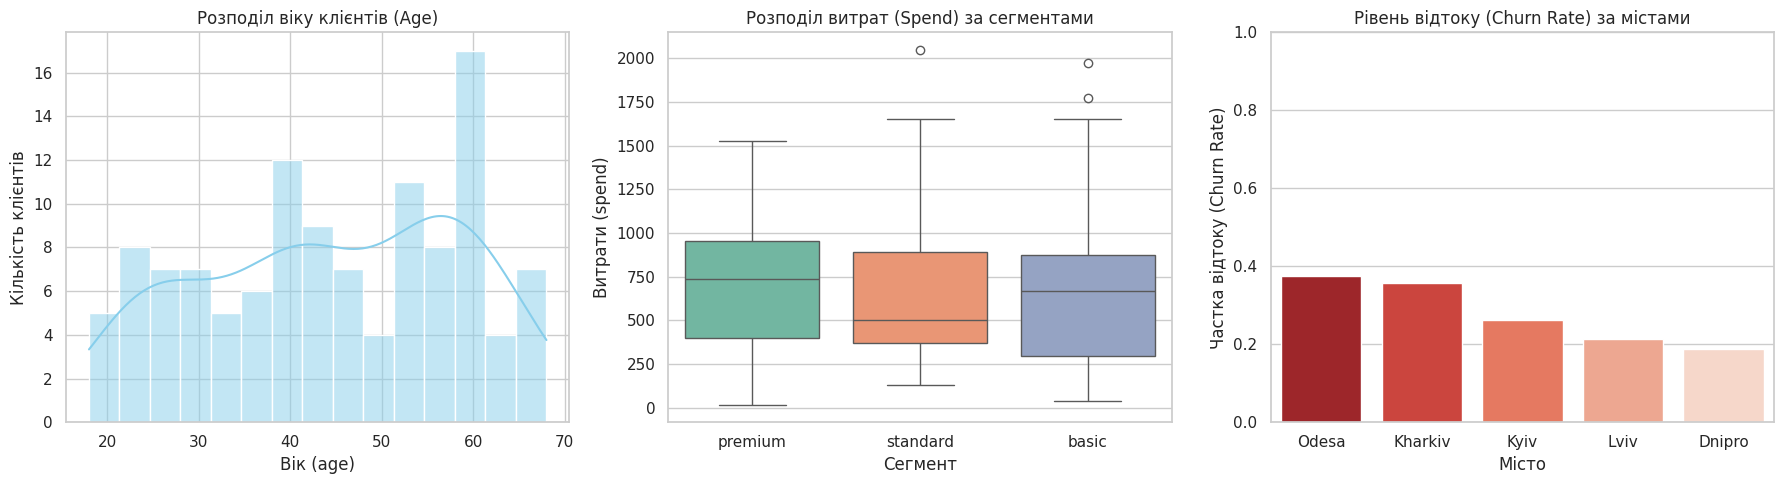

In [93]:
# TODO: Ваш код для завдання 8
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 5))

#1
plt.subplot(1, 3, 1)
sns.histplot(df_cleaned["age"], kde = True, color = "skyblue", bins = 15)
plt.title("Розподіл віку клієнтів (Age)", fontsize = 12)
plt.xlabel("Вік (age)")
plt.ylabel("Кількість клієнтів")

#2
plt.subplot(1, 3, 2)
sns.boxplot(data = df_cleaned, x = "segment", y = "spend", palette = "Set2")
plt.title("Розподіл витрат (Spend) за сегментами", fontsize = 12)
plt.xlabel("Сегмент")
plt.ylabel("Витрати (spend)")

#3
plt.subplot(1, 3, 3)
city_churn = df_cleaned.groupby("city")["churn"].mean().reset_index()
city_churn = city_churn.sort_values(by = "churn", ascending=False)

sns.barplot(data = city_churn, x = "city", y = "churn", palette = "Reds_r")
plt.title("Рівень відтоку (Churn Rate) за містами", fontsize = 12)
plt.xlabel("Місто")
plt.ylabel("Частка відтоку (Churn Rate)")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

### Інтерпретація побудованих графіків (Завдання 8):

1. **Розподіл віку клієнтів (`age`):**
   Гістограма демонструє віковий склад аудиторії компанії. Вона дозволяє визначити ключову вікову категорію клієнтів та перевірити наявність аномальних значень чи зміщень у розподілі.

2. **Boxplot витрат (`spend`) за сегментами:**
   Графік показує медіанні витрати, міжквартильний розмах та викиди для кожного сегмента (`basic`, `standard`, `premium`). Видно, що сегмент `premium` демонструє вищий рівень витрат порівняно з базовими сегментами.
3. **Рівень відтоку (`churn rate`) за містами:**
   Стовпчаста діаграма ілюструє частку втрачених клієнтів у кожному регіоні. Це дозволяє виявити міста з найвищим показником відтоку, які потребують першочергової уваги маркетингу та покращення сервісу.

**Чому це важливо:** Візуальний аналіз перетворює сирі цифри на наочні патерни, дозволяючи швидко оцінити формоутворення вікових груп, перевірити валідність сегментації та виявити проблемні регіони для зниження відтоку клієнтів.

## Завдання 9. Викиди
За правилом IQR знайдіть потенційні викиди `spend`.

Далі порівняйте середнє та медіану `spend` до і після **тимчасового** виключення цих рядків. Не видаляйте викиди з фінального DataFrame автоматично. Поясніть, чому.

In [100]:
# TODO: Ваш код для завдання 9
q1 = df_cleaned["spend"].quantile(0.25)
q3 = df_cleaned["spend"].quantile(0.75)
iqr = q3 - q1

low = q1 - 1.5 * iqr
high = q3 + 1.5 * iqr

outliers = df_cleaned[(df_cleaned["spend"] < low) | (df_cleaned["spend"] > high)]
print("Знайдено потенційних викидів:", len(outliers))

mean_before = df_cleaned["spend"].mean()
median_before = df_cleaned["spend"].median()

df_no_outliers = df_cleaned[(df_cleaned["spend"] >= low) & (df_cleaned["spend"] <= high)]

mean_after = df_no_outliers["spend"].mean()
median_after = df_no_outliers["spend"].median()

comparison = pd.DataFrame({
    "Показник": ["Середнє (Mean)", "Медіана (Median)"],
    "До виключення": [mean_before, median_before],
    "Після виключення": [mean_after, median_after],
    "Різниця": [mean_before - mean_after, median_before - median_after]
})

print("\nПорівняння метричних показників spend:")
comparison

Знайдено потенційних викидів: 3

Порівняння метричних показників spend:


,Показник,До виключення,Після виключення,Різниця
0,Середнє (Mean),680.208435,646.727679,33.480756
1,Медіана (Median),623.250000,612.160000,11.090000


### Висновок за результатами аналізу викидів (Завдання 9):

1. **Вплив викидів на метрики:**
   - **Середнє арифметичне (`mean`):** Дуже чутливе до екстремальних значень, тому виключення викидів суттєво зміщує середнє значення вбік менших чисел.
   - **Медіана (`median`):** Є стійкою метрикою, тож видалення викидів впливає на її значення не значною мірою, що підтверджує доцільність використання медіани для аналізу несиметричних даних.

2. **Чому НЕ можна автоматично видаляти викиди з фінального DataFrame:**
   - **Втрата інформації:** Автоматичне видалення спотворить реальний виторг компанії та приховає сегмент найприбутковіших користувачів.
   - **Сигнал для сегментації:** Замість видалення екстремальні витрати краще аналізувати як окрему групу (наприклад, сегмент `premium`).

**Чому це важливо:** Розуміння різниці між статистичними аномаліями та реальними бізнес-викидами запобігає втраті цінних даних про найприбутковіших клієнтів.

## Завдання 10. Підсумковий EDA
Підготуйте короткий аналітичний висновок за набором даних. Він має містити:
- розмір і структуру даних;
- проблеми якості;
- 3–5 ключових статистичних спостережень;
- щонайменше 2 візуальні спостереження;
- потенційні ознаки для ML-моделі прогнозування `churn`;
- ризики data leakage;
- план preprocessing перед моделюванням.

In [103]:
# TODO: За потреби додайте код для підсумкового аналізу
print(f"Розмірність датасету: {df_cleaned.shape[0]} рядків, {df_cleaned.shape[1]} стовпчиків")
print("\nТипи даних та пропуски:")
print(df_cleaned.info())

print("\nРозподіл цільової змінної Churn:")
print(df_cleaned["churn"].value_counts(normalize = True).round(3))

Розмірність датасету: 120 рядків, 11 стовпчиків

Типи даних та пропуски:
<class 'pandas.core.frame.DataFrame'>
Index: 120 entries, 0 to 119
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customer_id     120 non-null    int64         
 1   age             117 non-null    float64       
 2   city            120 non-null    object        
 3   segment         119 non-null    object        
 4   signup_date     120 non-null    datetime64[ns]
 5   orders          120 non-null    int64         
 6   spend           115 non-null    float64       
 7   churn           120 non-null    int64         
 8   signup_year     120 non-null    int32         
 9   signup_quarter  120 non-null    int32         
 10  tenure_days     120 non-null    int64         
dtypes: datetime64[ns](1), float64(2), int32(2), int64(4), object(2)
memory usage: 10.3+ KB
None

Розподіл цільової змінної Churn:
churn
0    0.725
1  

### Підсумковий аналітичний висновок EDA (Завдання 10)

**1. Розмір і структура даних**
* **Розмірність:** Датасет містить 120 рядків та 11 стовпчиків (`customer_id`, `age`, `city`, `segment`, `signup_date`, `orders`, `spend`, `churn`, `signup_year`, `signup_quarter`, `tenure_days`).
* **Структура:** Включає ідентифікаційні дані (`customer_id`), демографію (`age`, `city`), часові метрики (`signup_date`, `tenure_days`), поведінкові атрибути (`orders`, `spend`, `segment`) та цільову змінну `churn`.

**2. Проблеми якості даних**
* **Пропущені значення:** У початковому датасеті є пропуски (`age` — 117/120, `segment` — 119/120, `spend` — 115/120), які було оброблено під час очищення.
* **Дублікати та нетипові значення:** Видалено дубльовані записи та виявлено 3 потенційні викиди за IQR у колонці `spend`.

**3. Ключові статистичні спостереження**
* **Дисбаланс класів:** Цільова змінна `churn` є незбалансованою — 72.5% активних клієнтів (клас 0) та 27.5% відтоку (клас 1).
* **Правостороннє зміщення витрат:** Середнє значення `spend` (680.20) перевищує медіану (623.25) через наявність клієнтів із високим рівнем витрат.
* **Найприбутковіший сегмент:** Максимальна медіана витрат зафіксована у місті Дніпро для сегмента `premium` (1254.48).
* **Стійкість медіани:** Виключення 3 викидів майже не змінило медіану (з 623.25 до 612.16), на відміну від середнього значення.

**4. Візуальні спостереження**
* **Географія відтоку:** Найвищий рівень `churn rate` зафіксовано в Одесі та Харкові (35-37%), найнижчий — у Дніпрі (18%).
* **Розподіл за сегментами:** Boxplot показує, що сегмент `premium` має найвищу медіану витрат (~750) і не має викидів, тоді як у сегментах `standard` та `basic` спостерігається більший варіативний розмах і наявні екстремальні поодинокі викиди (понад 1750–2000).

**5. Потенційні ознаки для ML-моделі прогнозування churn**
* `tenure_days` та `orders` — тривалість перебування та активність замовлень.
* `city` — географічна прив'язка до регіонального відтоку.
* `spend` та `segment` — рівень фінансової цінності клієнта.

**6. Ризики Data Leakage (витоку даних)**
* **Прямий витік:** Використання ознак, які виникають уже після фактичного відтоку клієнта.
* **Витік при обробці:** Обчислення параметрів імпутації, кодування та масштабування (`mean`, `median`, `std`) на всьому датасеті до розділення на навчальну та тестову вибірки.

**7. План Preprocessing перед моделюванням**
1. **Розділення даних:** Стратифіковане розбиття на навчальну та тестову вибірки для збереження пропорції класів цільової змінної `churn` (72.5% до 27.5%).
2. **Кодування категоріальних ознак:** Застосування One-Hot Encoding для неупорядкованої змінної `city` та Ordinal Encoding для рангової змінної `segment`.
3. **Масштабування:** Використання RobustScaler для числових показників (`spend`, `tenure_days`), оскільки цей метод стійкий до наявних у даних викидів.
4. **Балансування класів:** Компенсація дисбалансу цільової змінної через параметри моделі (class_weight='balanced')

## Критерії самоперевірки

Робота виконана якісно, якщо:
- код запускається послідовно без помилок;
- вихідний DataFrame не змінюється випадково через неявні присвоєння;
- для вибірки за умовами використано `loc`;
- пропуски й дублікати не обробляються без пояснення;
- `merge` перевіряє очікувану кардинальність через `validate`;
- графіки мають назви та зрозумілі осі;
- висновки містять інтерпретацію, а не лише перелік чисел;
- при переході до ML враховано ризик витоку даних.